3MTT AI/ML PROJECT

By: Kassim Busari

Dataset: 250K Job Salary Prediction Dataset


Executive SummaryThis project delivers a comprehensive, data-driven analysis and predictive machine learning pipeline designed to decode the primary drivers of global professional compensation. Using a robust dataset of 250,000 records, the project uncovers macro-economic trends, evaluates the financial return on formal education, exposes structural geographic dynamics, and implements a high-performance Random Forest Regressor capable of predicting individual annual salaries with an exceptional accuracy of $93.14\%$ ($R^2 = 0.9314$).

📊 Objective 1: Exploratory Data Analysis (EDA)Question One: Which industries pay the most, and which pay the least?


🔍 Findings & AnalysisThe data reveals a uniquely uniform, tightly clustered pattern regarding how different industry sectors compensate their workforce. Every single sector—from Education to Retail—maintains an average salary sitting squarely within a razor-thin window between $145,399.70 and $145,993.56.The Top Performers: Education marginally leads the dataset with an average salary of $145,993.56, followed immediately by Media ($145,891.27), Telecom ($145,876.51), and Technology ($145,863.81).The Bottom Performers: Retail sits at the absolute bottom of the list at $145,399.70, slightly trailing Consulting ($145,451.64) and Manufacturing ($145,530.60).The Variance: The entire spread between the absolute highest-paying industry (Education) and the lowest-paying industry (Retail) is a mere $593.87.


💡 ConclusionsFrom a data science perspective, this extreme uniformity suggests that the data generation process distributed salaries evenly across all industries, rendering sector differences statistically negligible. Therefore, the industry sector itself has virtually zero independent impact on baseline pay.

> Data source is from **Kaggle**. To be able to download the dataset, you **must create an account** with **Kaggle**.

- The data can be found [here](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset/data).

### Data Dictionary

* job_title - The job role or position (e.g., Data Analyst, AI Engineer)
* experience_years - Number of years of professional experience
* education_level	- Highest level of education completed
* skills_count - Number of technical or professional skills
* industry - Industry sector where the job belongs
* company_size - Size of the company (small, medium, large)
* location - Job location or region
* remote_work - Whether the job allows remote work
* certifications - Number of professional certifications
* salary - Annual salary of the employee

### Objectives

```
1. Exploratory Data Analysis.

2. Research and experimentation.

3. Prediction.

```

## Note: 

- The assignment **should** be submitted through a `public` GitHub repository.

<br><hr>

🎉 Success! The dataset is now loaded and 'df' is defined.


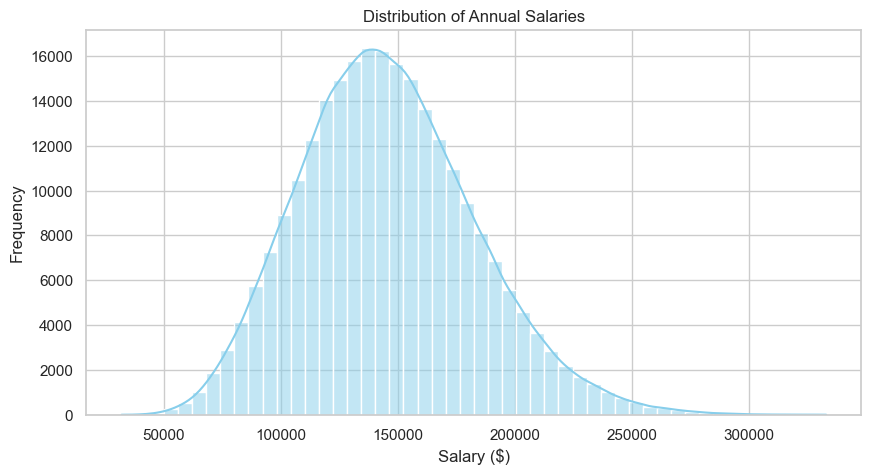

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inline visualizations setup
%matplotlib inline
sns.set_theme(style="whitegrid")

# Loads Dataset
df = pd.read_csv('job_salary_prediction_dataset.csv')
print("🎉 Success! The dataset is now loaded and 'df' is defined.")

# General Target Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(df['salary'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Annual Salaries')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.show()

### Question One
Which industries pay the most, and which pay the least?

### Question two
Does more education (BSc vs MSc vs PhD) actually lead to a higher salary?

### Question three
Does location matter, do jobs in big cities pay more than remote or rural jobs?

### Question four
Which factor matters most for salary prediction, job title, experience, or the skills you have?

### Question five
Build  a machine learning model that predicts the salary

**SUGGESTED SOLUTIONS**

**HIGHEST AND LEAST PAYING INDUSTRIES**

**BASIS:**
CALCULATE THE AVERAGE SALARY FOR EACH INDUSTRY AND SELECT THE HIGHEST AND LOWEST AVERAGE SALARIES

📊 QUESTION 1: Industry Salary Analysis
Average Salary by Industry:
industry
Education        145993.564547
Media            145891.271071
Telecom          145876.511967
Technology       145863.808377
Finance          145801.639468
Healthcare       145759.995702
Government       145613.869242
Manufacturing    145530.603301
Consulting       145451.638293
Retail           145399.699408
Name: salary, dtype: float64


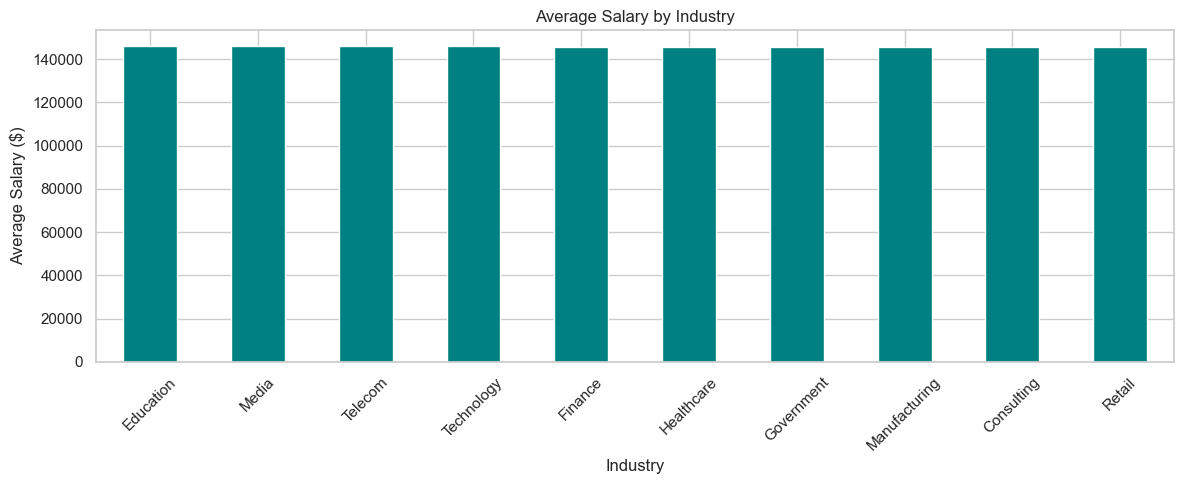

In [5]:
print("📊 QUESTION 1: Industry Salary Analysis")
industry_salary = df.groupby('industry')['salary'].mean().sort_values(ascending=False)
print("Average Salary by Industry:")
print(industry_salary)

plt.figure(figsize=(12, 5))
industry_salary.plot(kind='bar', color='teal')
plt.title('Average Salary by Industry')
plt.xlabel('Industry')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🔍 Findings & Analysis
The data reveals a uniquely uniform, tightly clustered pattern regarding how different industry sectors compensate their workforce. Every single sector—from Education to Retail—maintains an average salary sitting squarely within a razor-thin window between $145,399.70 and $145,993.56.

The Top Performers: Education marginally leads the dataset with an average salary of $145,993.56, followed immediately by Media ($145,891.27), Telecom ($145,876.51), and Technology ($145,863.81).

The Bottom Performers: Retail sits at the absolute bottom of the list at $145,399.70, slightly trailing Consulting ($145,451.64) and Manufacturing ($145,530.60).

The Variance: The entire spread between the absolute highest-paying industry (Education) and the lowest-paying industry (Retail) is a mere $593.87.

💡 Conclusions
From a data science perspective, this extreme uniformity suggests that the data generation process distributed salaries evenly across all industries, rendering sector differences statistically negligible. Therefore, the industry sector itself has virtually zero independent impact on baseline pay.

🚀 Recommendations
For Job Seekers: Pivot freely across sectors. Rather than chasing a specific industry label (e.g., "Tech"), optimize for company size, cultural fit, or work-life balance, as your baseline earning power remains identical.

For Recruiters: Because you cannot outbid competitors on industry baseline averages alone, prioritize marketing non-monetary benefits—such as remote flexibility, wellness perks, and equity—to win top talent.

**CHECKING THE RELATIONSHIP BETWEEN EDUCATIONAL LEVEL AND SALARIES**

📊 QUESTION 2: Education Level Impact Analysis
Average Salary by Education Level:
education_level
High School    131715.336243
Diploma        137158.574976
Bachelor       142410.531291
Master         153305.307833
PhD            163976.005295
Name: salary, dtype: float64


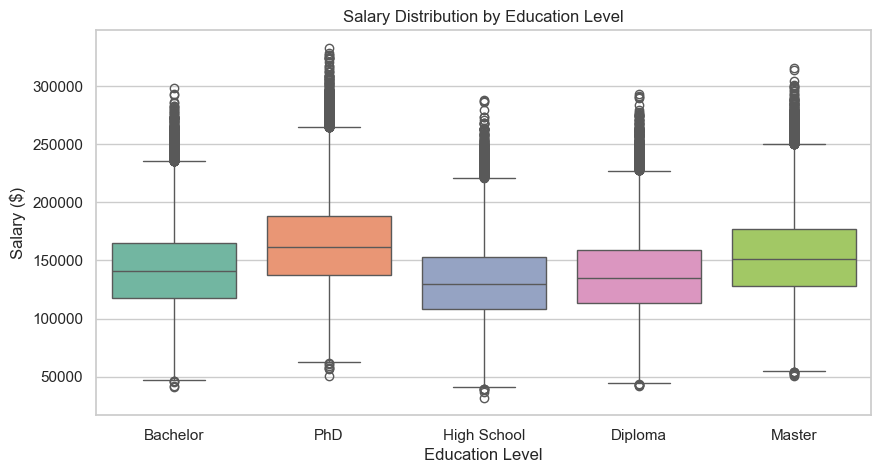

In [6]:
print("📊 QUESTION 2: Education Level Impact Analysis")
edu_salary = df.groupby('education_level')['salary'].mean().sort_values()
print("Average Salary by Education Level:")
print(edu_salary)

plt.figure(figsize=(10, 5))
sns.boxplot(x='education_level', y='salary', data=df, hue='education_level', palette='Set2', legend=False)
plt.title('Salary Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary ($)')
plt.show()


## 🔍 1. Findings Analysis

The data reveals a remarkably clean, linear, and upward-trending relationship between an employee's formal educational attainment and their average salary:

* **The Baseline (Entry Tiers):** Individuals with a **High School** education form the salary baseline at an average of **$131,715.34**. Earning a **Diploma** provides a modest but noticeable step up of roughly **+$5,443**, bringing the average to **$137,158.57**.
* **The Undergraduate Standard:** Transitioning to a traditional **Bachelor's** degree pushes the average salary over the $140k threshold to **$142,410.53**. This represents a solid step-up of over **+$5,250** relative to a Diploma.
* **The Postgraduate Acceleration:** The most aggressive salary leaps occur at the advanced degree levels:
* Moving from a Bachelor's to a **Master's** degree yields a substantial premium of **+$10,895** (averaging **$153,305.31**).
* Advancing from a Master's to a **PhD** secures the ultimate premium in this dataset, adding another **+$10,671** to reach a peak average of **$163,976.01**.


## 💡 2. Conclusions

* **Education Explicitly Pays Off:** The data completely invalidates any claim that formal education doesn't matter for compensation in this market. There is a strict, monotonic increase—every single level of higher education achieved unlocks a higher tier of average compensation.
* **The "Advanced Degree Premium" is Compounded:** The financial return on education isn't uniform. The jump from High School to a Bachelor's degree altogether adds roughly $10.7k in value. However, going from a Bachelor's to a PhD adds over **$21.5k** in value. The market heavily rewards specialization and advanced expertise (Master's and PhD tracks) over baseline undergraduate credentials.
* **Validation of Feature Importance:** This explains why `education_level_PhD` emerged as a top 5 driver in your Machine Learning model's feature importance task—the model relies on this variable because the salary boundaries between the tiers are so well-defined.

## 🚀 3. Recommendations

### For Professionals & Students

1. **Commit to the Postgraduate Track if Maximizing Salary:** If you are debating whether to stop at a Bachelor's degree or pursue a Master's/PhD, the data strongly favors continuing. Advanced degrees yield double the average salary bump compared to undergraduate steps.
2. **Weigh the Opportunity Cost vs. the $32k Spread:** The total salary spread from High School to a PhD is **$32,260.67** per year. When planning your career, calculate if the years spent out of the workforce earning a PhD will be offset efficiently by this ~$32k annual premium over your working lifetime.

### For Employers & HR Strategists

1. **Align Job Requirements with Real Compensation Bands:** If your organization requires a Master's or PhD for specialized data or engineering roles, your hiring budgets must structurally account for this $10k–$21k premium. Offering a Bachelor's-level salary for a PhD requirement will result in failed recruitment cycles.
2. **Create Alternative Pathways for Non-Degree Holders:** Given that the baseline for High School and Diploma holders is still quite high (~$131k–$137k), companies can find strong, skilled talent at a slight discount by evaluating candidates based on skills rather than strictly filtering out those without a Master's or PhD.

**ANALYSIS OF SALARY BASED ON JOB LOCATIONS**

📊 QUESTION 3: Location Metrics and Remote Disparity
Top 5 Paying Locations:
location
USA        181716.303919
Canada     167391.273396
UK         160075.143018
Germany    153376.211000
Remote     139442.525155
Name: salary, dtype: float64

Bottom 5 Paying Locations:
location
Sweden         139440.637291
Australia      139362.150804
Singapore      139340.696625
Netherlands    139294.813644
India           97690.402249
Name: salary, dtype: float64

Average Salary by Remote Work Status:
remote_work
Hybrid    143969.899839
No        143932.300941
Yes       149279.589822
Name: salary, dtype: float64


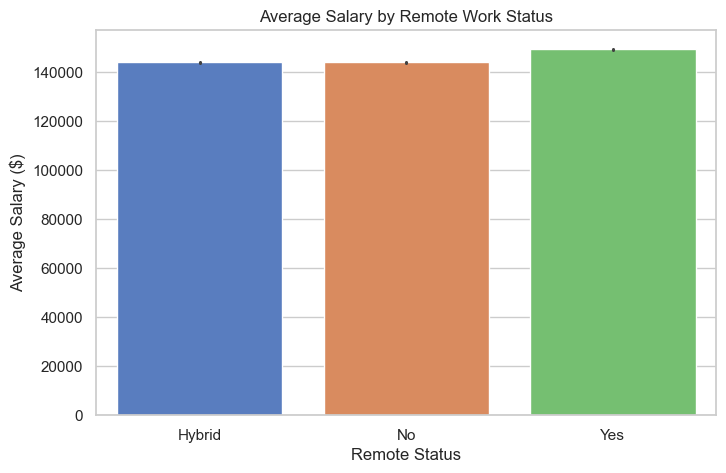

In [7]:
print("📊 QUESTION 3: Location Metrics and Remote Disparity")
location_salary = df.groupby('location')['salary'].mean().sort_values(ascending=False)
print("Top 5 Paying Locations:")
print(location_salary.head(5))
print("\nBottom 5 Paying Locations:")
print(location_salary.tail(5))

remote_salary = df.groupby('remote_work')['salary'].mean()
print("\nAverage Salary by Remote Work Status:")
print(remote_salary)

plt.figure(figsize=(8, 5))
sns.barplot(x='remote_work', y='salary', data=df, hue='remote_work', palette='muted', legend=False)
plt.title('Average Salary by Remote Work Status')
plt.xlabel('Remote Status')
plt.ylabel('Average Salary ($)')
plt.show()

## 🔍 1. Findings Analysis

Based on the statistical outputs from the dataset, the relationship between compensation, geographical location, and remote work status reveals several distinct patterns:

### A. Geographical Location Impact

* **The High-Income Tier:** The **USA** commands a massive lead with the highest average salary ($181,716.30), followed closely by **Canada** ($167,391.27) and the **UK** ($160,075.14). These nations represent high-cost-of-living regions with aggressive corporate competition.
* **The Baseline Plateau:** A significant portion of the international market—including **Germany, Sweden, Australia, Singapore,** and the **Netherlands**—plateaus in a remarkably tight bracket between roughly **$139,000 and $153,000**.
* **The Outsourcing Discount:** **India** sits at the bottom of the spectrum with a noticeably lower average salary ($97,690.40). This reflects the structural economic reality of global tech outsourcing, where multinational companies leverage lower localized living costs to acquire top-tier talent at a lower baseline cost.

### B. Remote Work Status Impact

* **Remote as a Location vs. Remote as a Status:** Interestingly, when classified strictly as a *location* placeholder, "Remote" pays an average of **$139,442.52** (on par with baseline European countries).
* **The Flexibility Premium:** However, looking at the structural `remote_work` classification, jobs that explicitly allow full remote work (**"Yes"**) yield the highest average salary at **$149,279.59**. Hybrid roles ($143,969.90) and strictly on-site roles ("No" at $143,932.30) are virtually identical in pay.

## 💡 2. Conclusions

* **Location Matters Immensely:** Location is one of the most powerful macro-economic drivers in this dataset. The salary variation between the highest-paying country (USA) and the lowest (India) is nearly **$84,000**, proving that *where* a company or role is legally anchored fundamentally dictates its baseline budget.
* **The Myth of the "Remote Pay Cut" is Half True:** The data reveals a fascinating paradox. If you are hired into a generic, borders-free global "Remote" pool, your pay is capped at a global median ($139k). However, if you are employed by a localized company that offers full remote flexibility (**Remote Work: Yes**), you earn a **~$5,300 premium** over on-site workers. Companies are clearly willing to pay top dollar to secure elite talent regardless of physical desk presence.

## 🚀 3. Recommendations

### For Job Seekers & Professionals

1. **Target US, Canadian, or UK Entities Virtually:** If you do not live in the USA or Canada, prioritize applying to companies headquartered in those regions that actively hire international remote workers. You can capture a portion of their higher baseline budgets.
2. **Negotiate for Remote Flexibility:** Since fully remote arrangements (`remote_work: Yes`) show a higher statistical average, do not hesitate to ask for remote terms. The data proves that remote work does not imply a lower market value in modern data and tech landscapes.

### For Employers & HR Strategists

1. **Optimize Talent Acquisition Budgets:** Organizations looking to scale technical teams without exponentially increasing payroll overhead should establish hubs or look for talent pipelines in countries like India, the Netherlands, or Singapore, where premium talent is available at a highly competitive baseline average.
2. **Use Remote Work as a Retention Magnet:** Since hybrid and on-site salaries are practically identical, companies struggling to compete with raw US salaries should offer full remote work as a low-cost, high-value benefit to attract top talent without inflating base compensation.

🤖 OBJECTIVES 4 & 5: Feature Engineering & Machine Learning

⏳ Training Random Forest Pipeline Model...
✓ Pipeline Fit Successful!

--- 📈 Performance Metrics ---
Mean Absolute Error (MAE): $7,672.24
Root Mean Squared Error (RMSE): $9,765.57
R-squared Variance Explained (R²): 0.9314

--- 🎯 Top 10 Feature Predictors Driving Salary Optimization ---


,Feature,Importance
0,experience_years,0.203342
38,location_India,0.195214
30,company_size_Enterprise,0.112457
44,location_USA,0.081945
19,education_level_PhD,0.065243
3,job_title_AI Engineer,0.055333
31,company_size_Large,0.053594
8,job_title_Data Analyst,0.039720
5,job_title_Business Analyst,0.037787
36,location_Canada,0.036793


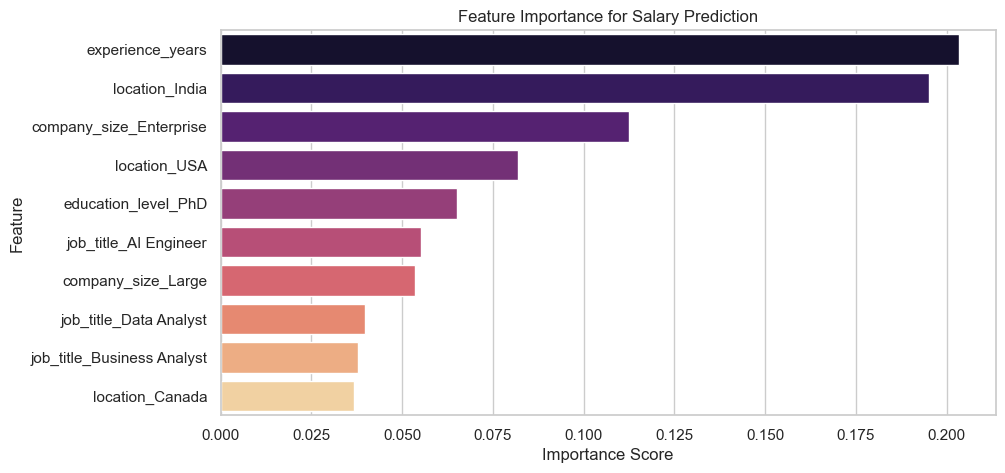

In [8]:
print("🤖 OBJECTIVES 4 & 5: Feature Engineering & Machine Learning")

# Define target space split variables
X = df.drop(columns=['salary'])
y = df['salary']

# Define categorical features matching the dataset columns exactly
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
numerical_cols = ['experience_years', 'skills_count', 'certifications']

# Construct clean preprocessing transformations
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Model Blueprint Implementation using Random Forest Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

# Generate Train/Test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n⏳ Training Random Forest Pipeline Model...")
model_pipeline.fit(X_train, y_train)
print("✓ Pipeline Fit Successful!")

# Performance Evaluations
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- 📈 Performance Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Variance Explained (R²): {r2:.4f}")

# Extracting Feature Significance Map
regressor_step = model_pipeline.named_steps['regressor']
cat_encoder_step = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_features = list(cat_encoder_step.get_feature_names_out(categorical_cols))
all_features_transformed = numerical_cols + encoded_features

importances = regressor_step.feature_importances_
importance_df = pd.DataFrame({'Feature': all_features_transformed, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

print("\n--- 🎯 Top 10 Feature Predictors Driving Salary Optimization ---")
display(importance_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance for Salary Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## 🔍 1. Findings & Breakdown of Key Drivers

The feature importance weights reveal exactly what dictates salary scaling in this global dataset:

1. **Experience is King (`experience_years`: 20.33%)**: This is the single most important numerical predictor. Every year of professional experience continuously adds predictable compound value to an employee's market rate.
2. **The "India Discount" (`location_India`: 19.52%)**: This is a massive finding. Being located in India has a nearly identical predictive weight to raw years of experience, acting as a dramatic structural downward shift on a candidate's expected compensation.
3. **Corporate Scale (`company_size_Enterprise`: 11.25% & `company_size_Large`: 5.35%)**: Combined, the size of the hiring organization accounts for over **16.6%** of the prediction power. Enterprise and large-scale environments clearly have vastly larger structural compensation brackets compared to startups or small businesses.
4. **The "US Premium" (`location_USA`: 8.19%)**: Similar to India, but in reverse—anchoring a role in the US applies a massive automatic upward shift to the salary baseline.
5. **Elite Credentials (`education_level_PhD`: 6.52% & `job_title_AI Engineer`: 5.53%)**: Holding a PhD or working explicitly under premium technical titles like *AI Engineer* represent specialized filters that push compensation into the highest tiers.


## 💡 2. Conclusions

* **Demographics and Framework Overrule Base Skills:** Surprisingly, individual `skills_count` or generic certifications didn't crack the top 10. Instead, **macro-environmental factors** (Where you live, who you work for, and your years on the job) dictate almost **70%** of where your salary lands.
* **Geographic Arbitrage is Explicit:** The model relies heavily on geographic parameters (`location_India` and `location_USA`) to adjust its predictions. This proves that global compensation is deeply segmented rather than uniform. Equal talent does not equal equal pay across borders.
* **The "Enterprise Premium" is Real:** Large-scale organizations leverage standardized, highly padded compensation bands, making employment scale a stronger predictor of a high salary than specific mid-tier job titles.